In [1]:

# # Scaling Law demo: Loss vs Number of Parameters (N) on IMDB (subset)

# %%capture
!pip -q install transformers datasets evaluate accelerate scipy matplotlib pandas

# %%
import os, math, numpy as np, pandas as pd, torch, random
from datasets import load_dataset
from transformers import (
    BertTokenizerFast, BertConfig, BertForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding, set_seed
)
import evaluate
from scipy.stats import linregress
import matplotlib.pyplot as plt

set_seed(42)
torch.backends.cuda.matmul.allow_tf32 = True
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

# %%
# 1) Datos: tomamos un subset pequeño para que corra rápido
raw_train = load_dataset("imdb", split="train[:5000]")
raw_valid = load_dataset("imdb", split="test[:2000]")

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
max_len = 128

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=max_len)

train_ds = raw_train.map(tokenize, batched=True, remove_columns=["text"])
valid_ds = raw_valid.map(tokenize, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2) Métrica (opcional, no la usamos para el ajuste de la scaling law)
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return acc_metric.compute(predictions=preds, references=labels)

# %%
# 3) Definimos configuraciones que cambian el tamaño del modelo (N)
#    - Todas son BERT "from scratch" con distintas dimensiones.
model_configs = {
    "tiny":  dict(num_hidden_layers=2, hidden_size=128, intermediate_size=512,  num_attention_heads=2),
    "small": dict(num_hidden_layers=4, hidden_size=256, intermediate_size=1024, num_attention_heads=4),
    "base":  dict(num_hidden_layers=6, hidden_size=512, intermediate_size=2048, num_attention_heads=8),
    "large": dict(num_hidden_layers=8, hidden_size=768, intermediate_size=3072, num_attention_heads=12),
}

# 4) Bucle de entrenamiento: fijamos el mismo presupuesto de pasos para todos
results = []
max_steps = 400            # pequeño para demo; sube si tienes más GPU
batch_size = 16
lr = 3e-4
warmup = 50

for name, cfg in model_configs.items():
    print(f"\n=== Entrenando modelo: {name} ===")
    # Config BERT desde cero
    config = BertConfig(
        vocab_size=tokenizer.vocab_size,
        hidden_size=cfg["hidden_size"],
        num_hidden_layers=cfg["num_hidden_layers"],
        num_attention_heads=cfg["num_attention_heads"],
        intermediate_size=cfg["intermediate_size"],
        max_position_embeddings=512,
        num_labels=2
    )
    model = BertForSequenceClassification(config).to(device)

    # Contar parámetros entrenables (N)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Argumentos de entrenamiento (mismo # de pasos para todos)
    args = TrainingArguments(
        output_dir=f"./out_{name}",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_steps=warmup,
        max_steps=max_steps,                  # <-- presupuesto fijo
        gradient_accumulation_steps=1,
        #evaluation_strategy="steps",
        eval_steps=max_steps,                 # solo evaluamos al final
        logging_steps=50,
        save_steps=max_steps,                 # guardar al final
        save_total_limit=1,
        report_to="none",
        load_best_model_at_end=False,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_res = trainer.evaluate()
    eval_loss = float(eval_res["eval_loss"])
    eval_acc  = float(eval_res.get("eval_accuracy", float("nan")))

    results.append(dict(model=name, params=n_params, loss=eval_loss, acc=eval_acc))

results_df = pd.DataFrame(results).sort_values("params")
results_df


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Step,Training Loss
50,0.056900
100,0.000100
150,0.000000
200,0.000000
250,0.000000
300,0.000000
350,0.000000
400,0.000000



=== Entrenando modelo: large ===


/tmp/ipython-input-3565345347.py:99: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,0.037900
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000
350,0.000000
400,0.000000


,model,params,loss,acc
0,tiny,4386178,0.001377,1.0
1,small,11171074,0.000260,1.0
2,base,35069442,0.000020,1.0
3,large,81132290,0.000002,1.0


Pendiente (logL vs logN): -2.2006
α (estimado) ≈ 2.2006
R^2 ≈ 0.9946


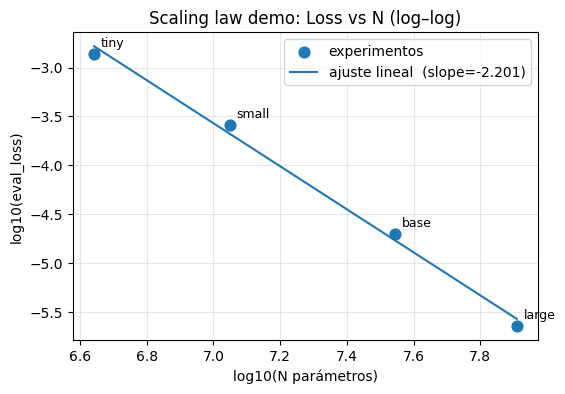

,model,params,loss,acc
0,tiny,4386178,0.001377,1.0
1,small,11171074,0.000260,1.0
2,base,35069442,0.000020,1.0
3,large,81132290,0.000002,1.0


In [2]:

# ## Ajuste de la scaling law: log–log (Loss vs N)

# %%
params = results_df["params"].to_numpy(dtype=float)
losses = results_df["loss"].to_numpy(dtype=float)

# Log10
logN  = np.log10(params)
logL  = np.log10(losses)

slope, intercept, r, p, stderr = linregress(logN, logL)
alpha_est = -slope  # pendiente negativa -> -alpha

print(f"Pendiente (logL vs logN): {slope:.4f}")
print(f"α (estimado) ≈ {alpha_est:.4f}")
print(f"R^2 ≈ {r**2:.4f}")

# Plot
plt.figure(figsize=(6,4))
plt.scatter(logN, logL, s=60, label="experimentos")
x_line = np.linspace(logN.min(), logN.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, label=f"ajuste lineal  (slope={slope:.3f})")
for i, row in results_df.iterrows():
    plt.annotate(row["model"], (np.log10(row["params"]), np.log10(row["loss"])), xytext=(5,5), textcoords="offset points", fontsize=9)

plt.xlabel("log10(N parámetros)")
plt.ylabel("log10(eval_loss)")
plt.title("Scaling law demo: Loss vs N (log–log)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

results_df
